# PART8_Breeding_plan

Simulate breeding plan based on recombination simulation

In [1]:
import random
import copy
import ast
import math
import numpy as np
import pandas as pd
import pickle
from tqdm import tqdm

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline
%config InlineBackend.figure_formats = {'png', 'retina'}
sns.set()

from sklearn.linear_model import ElasticNet
from modules.make_data_for_prediction import make_data
from modules.breeding import make_regional_info, get_top_regions, visualize_RIL_genotype
from modules.simulation import get_input_for_recombination, get_recombination_points, convert_genotype_to_pair, cross, check_target_regions, check_approximate_Hitomebore_ratio

# basic variables
family_list = pd.read_csv("../data/family_list.csv")
family = family_list.family.unique()
phenotype = "../data/phenotype_data/mean_phenotypes.csv"
CV = 5

## Marker design

assume around 50 markers for selection process

In [2]:
# genome size
total_length = sum(pd.read_csv("../data/chromosome_length.csv").length.values)

# get recombination points from NAM
with open('../data/PART0_NAM_stats/recombination_stats_500kbp.pic.bin', 'rb') as p:
    recombination_info = pickle.load(p)

NA_contain_RILs = recombination_info[recombination_info["count"] == -1].id.unique()
recombination_info = recombination_info[~recombination_info.id.isin(NA_contain_RILs)]
input_recom_data = get_input_for_recombination(recombination_info)

# genotype with start and end
genotype = pd.read_csv("../data/PART1_make_Haplotype_block/Haplotype_all_LD90.csv")
chr_ends = []
for i, each_chr in enumerate(genotype.chr.unique()):
    chr_genotype = genotype[genotype["chr"] == each_chr]
    pos_array = chr_genotype.pos.str.split("_", expand=True).values.flatten()
    pos_array = pos_array[pos_array != None].astype("int")
    end = pos_array.max()
    chr_ends.append(end)
pos_array = genotype.pos.str.split("_", expand=True).values
pos = np.array([[int(each_pos[0]), int(each_pos[0])] if each_pos[1] == None else [int(each_pos[0]), int(each_pos[1])] for each_pos in pos_array])
genotype["start"] = pos[:, 0]
genotype["end"] = pos[:, 1]

In [22]:
# get target regions indices of genotype data
imp_data = pd.read_csv("../data/PART7_Select_useful_RILs/Haplotype_high_imp_HBs_for_3traits_add.csv", dtype={'N01':str,'N03':str,'N04':str,'N05':str,'N06':str,'N07':str,'N08':str,'N09':str,'N10':str,'N11':str,'N12':str,'N13':str,'N14':str,'N16':str,'N17':str,'N18':str,'N19':str,'N20':str,'N21':str,'N22':str})

pop = "N01"
regional_info_all = make_regional_info(imp_data, 1000000, "../data/PART7_Select_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv", pop)
N01_GN_top_regions = get_top_regions(regional_info_all, "GN_imps", "top", 3)
N01_GN_top_regions_indices = []
for i in N01_GN_top_regions:
    N01_GN_top_regions_indices.extend(genotype[(genotype.chr == i[0]) & (genotype.start >= i[1]) & (genotype.end <= i[2]) & (genotype.N01_162 == 2)].index.values)

pop = "N17"
regional_info_all = make_regional_info(imp_data, 1000000, "../data/PART7_Select_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv", pop)
N17_GN_top_regions = get_top_regions(regional_info_all, "GN_imps", "top", 3)
N17_GN_top_regions_indices = []
for i in N17_GN_top_regions:
    N17_GN_top_regions_indices.extend(genotype[(genotype.chr == i[0]) & (genotype.start >= i[1]) & (genotype.end <= i[2]) & (genotype.N17_071 == 2)].index.values)

pop = "N08"
regional_info_all = make_regional_info(imp_data, 1000000, "../data/PART7_Select_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv", pop)
N08_PN_top_regions = get_top_regions(regional_info_all, "PN_imps", "top", 3)
N08_PN_top_regions_indices = []
for i in N08_PN_top_regions:
    N08_PN_top_regions_indices.extend(genotype[(genotype.chr == i[0]) & (genotype.start >= i[1]) & (genotype.end <= i[2]) & (genotype.N08_011 == 2)].index.values)

In [4]:
# get marker info for prediction model
marker_for_pred = imp_data.loc[:, ["chr", "start", "end"]]
marker_for_pred["key"] = marker_for_pred["chr"] + "_" + marker_for_pred["start"].astype("str") + "_" + marker_for_pred["end"].astype("str")

In [5]:
# marker list
# keep marker: beneficial regions
# drop marker: detrimental regions
N01_keep_marker_list = [[34303, 35049], [350, 1262], [29062, 29936]]
N08_keep_marker_list = [[20229, 21153], [56277, 56964]]
N17_keep_marker_list = [[624, 1450], [29254, 30167], [26960, 27486]]
N18_keep_marker_list = [[20500, 21132], [42128, 42557], [55308, 56276]]
N01_drop_marker_list = [[2636, 3713], [6857, 8547], [10886, 11845],[11858, 11965], [13089, 13787], [14278, 14506], [16922, 16949], [16950, 17819], [20314, 20504], [21631, 21674], [21677, 21962], [26167, 28462], [38200, 39517], [41461, 41920], [42778, 45233], [46432, 47905], [50254, 52526], [56261, 57080]]
N08_drop_marker_list = [[2698, 4760], [16123, 16942], [20044, 20100], [21440, 21577], [21677, 22021], [24718, 25816], [31325, 32235], [35069, 35430], [36325, 38191], [39522, 40592], [42677, 42743], [46108, 46429], [46432, 47262], [48260, 52526], [52826, 56174]]
N17_drop_marker_list = [[3504, 3597], [5894, 7704], [10415, 10648], [11963, 11973], [12621, 13371], [15485, 15887], [18397, 18430], [23356, 24180], [30398, 30776], [35066, 36302], [36595, 38480], [40591, 41253], [41626, 42136], [46343, 46429], [47973, 49111], [52530, 52571], [55261, 55286], [56272, 57081]]
N18_drop_marker_list = [[0, 267], [6798, 11844], [13589, 15668], [16950, 18430], [18661, 20437], [22733, 22742], [23051, 24443], [27888, 30395], [30410, 30890], [31215, 33275], [34252, 35061], [35194, 36685], [39522, 41920], [50954, 52306], [52529, 55269], [56325, 57080]]

In [6]:
def make_visualize_markers(genotype, marker_list):
    tmp_markers = []
    for i in marker_list:
        tmp_marker_region = genotype.iloc[i[0]:i[1]]
        region_width = tmp_marker_region.end.values[-1] - tmp_marker_region.start.values[0]
        if region_width < 2500000:
            tmp_markers.append([tmp_marker_region.chr.values[0], tmp_marker_region.start.values[0], tmp_marker_region.start.values[0]+500000])
        elif region_width < 5000000:
            tmp_markers.append([tmp_marker_region.chr.values[0], tmp_marker_region.start.values[0], tmp_marker_region.start.values[0]+500000])
            tmp_markers.append([tmp_marker_region.chr.values[0], tmp_marker_region.start.values[-1], tmp_marker_region.start.values[-1]+500000])            
        else:
            for j in np.linspace(tmp_marker_region.start.values[0], tmp_marker_region.start.values[-1], region_width // 2500000, endpoint = True, retstep = False, dtype = int):
                tmp_markers.append([tmp_marker_region.chr.values[0], j, j+500000])
    return tmp_markers 

def make_marker_index(genotype, marker_positions, RIL_id):
    marker_index = []
    for i in marker_positions:
        tmp_genotype = genotype.loc[(genotype.chr == i[0]) & (genotype[RIL_id] != 0)]
        marker_index.append(tmp_genotype[(tmp_genotype.start <= i[1])].index.values[-1])
    return marker_index

## Visualize markers
and make marker indices for breeding simulation

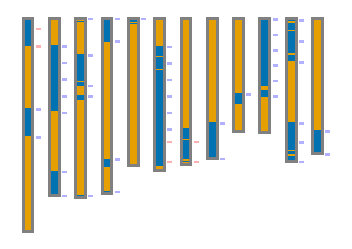

In [7]:
# makers for N01_162
tmp_genotype = genotype.loc[:, ["chr", "start", "end", "N01_162"]]
N01_keep_markers_vis = make_visualize_markers(genotype, N01_keep_marker_list)
N01_drop_markers_vis = make_visualize_markers(genotype, N01_drop_marker_list)
visualize_RIL_genotype(tmp_genotype, chr_ends, "#E69F00", "#0072B2", N01_keep_markers_vis, N01_drop_markers_vis, 80)
N01_keep_marker_index = make_marker_index(tmp_genotype, N01_keep_markers_vis, "N01_162")
N01_drop_marker_index = make_marker_index(tmp_genotype, N01_drop_markers_vis, "N01_162")

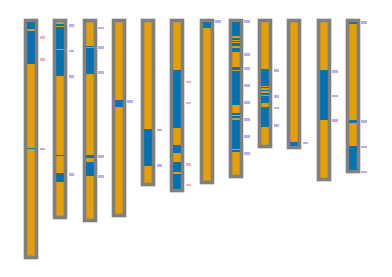

In [8]:
# makers for N17_071
tmp_genotype = genotype.loc[:, ["chr", "start", "end", "N17_071"]]
N17_keep_markers_vis = make_visualize_markers(genotype, N17_keep_marker_list)
N17_drop_markers_vis = make_visualize_markers(genotype, N17_drop_marker_list)
visualize_RIL_genotype(tmp_genotype, chr_ends, "#E69F00", "#0072B2", N17_keep_markers_vis, N17_drop_markers_vis, 80)
N17_keep_marker_index = make_marker_index(tmp_genotype, N17_keep_markers_vis, "N17_071")
N17_drop_marker_index = make_marker_index(tmp_genotype, N17_drop_markers_vis, "N17_071")

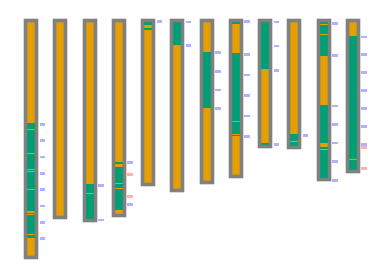

In [9]:
# makers for N08_011
tmp_genotype = genotype.loc[:, ["chr", "start", "end", "N08_011"]]
N08_keep_markers_vis = make_visualize_markers(genotype, N08_keep_marker_list)
N08_drop_markers_vis = make_visualize_markers(genotype, N08_drop_marker_list)
visualize_RIL_genotype(tmp_genotype, chr_ends, "#E69F00", "#009E73", N08_keep_markers_vis, N08_drop_markers_vis, 80)
N08_keep_marker_index = make_marker_index(tmp_genotype, N08_keep_markers_vis, "N08_011")
N08_drop_marker_index = make_marker_index(tmp_genotype, N08_drop_markers_vis, "N08_011")

# Simulate breeding plan

## Prepare material RILs & Hitomebore genotype

In [23]:
# make genotype dataframe for simulation
genotype_Hitomebore = genotype.loc[:, ["chr", "start", "end"]]
genotype_Hitomebore = pd.concat([genotype_Hitomebore,
                                 pd.DataFrame({"Hitomebore_1"      :np.repeat(0, genotype_Hitomebore.shape[0]),
                                               "Hitomebore_1_color":np.repeat("Hitomebore", genotype_Hitomebore.shape[0]),
                                               "Hitomebore_2"      :np.repeat(0, genotype_Hitomebore.shape[0]),
                                               "Hitomebore_2_color":np.repeat("Hitomebore", genotype_Hitomebore.shape[0])})], axis=1)
genotype_N01_162 = pd.concat([genotype.loc[:, ["chr", "start", "end"]],
                              convert_genotype_to_pair(genotype["N01_162"].values, "N01_162")], axis=1)
genotype_N17_071 = pd.concat([genotype.loc[:, ["chr", "start", "end"]],
                              convert_genotype_to_pair(genotype["N17_071"].values, "N17_071")], axis=1)
genotype_N08_011 = pd.concat([genotype.loc[:, ["chr", "start", "end"]],
                              convert_genotype_to_pair(genotype["N08_011"].values, "N08_011")], axis=1)
genotype_N18_227 = pd.concat([genotype.loc[:, ["chr", "start", "end"]],
                              convert_genotype_to_pair(genotype["N18_227"].values, "N18_227")], axis=1)

# Simulation 

In [24]:
RIL_info = {
    "N01_162": [genotype_N01_162, N01_GN_top_regions_indices],
    "N17_071": [genotype_N17_071, N17_GN_top_regions_indices],
    "N08_011": [genotype_N08_011, N08_PN_top_regions_indices],
    "N18_227": [genotype_N18_227, N18_PN_top_regions_indices],
}

In [25]:
def BCF2(RIL, genotype_RIL, genotype_Hitomebore, input_recom_data, simulation_num):
    BCF1_genotype = cross(genotype_RIL, genotype_Hitomebore, RIL, "Hitomebore", "BCF1", input_recom_data)
    BCF2_genotypes = []
    for i in range(simulation_num):
        BCF2_genotypes.append(cross(BCF1_genotype, BCF1_genotype, "BCF1", "BCF1", "BCF2", input_recom_data))
    return BCF2_genotypes

def get_genotypes_with_targets(genotype_list, name, marker_list):
    genotype_list_with_targets = []
    genotype_list_with_targets_homo = []
    for each_genotype in genotype_list:
        marker_genotype = each_genotype.loc[np.array(marker_list).flatten(), [f"{name}_1", f"{name}_2"]].sum(axis=1)
        if (marker_genotype > 0).sum() == len(np.array(marker_list).flatten()):
            genotype_list_with_targets.append(each_genotype)
        if (marker_genotype == 2).sum() == len(np.array(marker_list).flatten()):
            genotype_list_with_targets_homo.append(each_genotype)
    return genotype_list_with_targets, genotype_list_with_targets_homo

def get_sum_of_marker_genotype(genotype_list, name, marker_list):
    sum_marker = []
    for each_genotype in genotype_list:
        sum_marker.append(each_genotype.loc[np.array(marker_list).flatten(), [f"{name}_1", f"{name}_2"]].sum().sum())
    return np.array(sum_marker)

# Simulate New cultivar from N17_071 & N08_011

In [13]:
random.seed(121)

simulation_times = 100
Final_cultivars_Hitome_ratio = []
Final_cultivars_genotype = []
Final_cultivars_homo = []
fav_progenie_nums = []

# simulate XXX times
for i in tqdm(range(simulation_times)):
    
    BCF2_num = 100
    # N17_071 x Hitomebore -> BCF1 -> 100 BCF2 
    # -> random select 1 BCF2 with target variants
    BCF2_N17_071 = BCF2("N17_071", RIL_info["N17_071"][0], genotype_Hitomebore, input_recom_data, BCF2_num)
    BCF2_N17_071_with_target, BCF2_N17_071_with_target_homo = get_genotypes_with_targets(BCF2_N17_071, "BCF2", N17_keep_marker_index)
    if len(BCF2_N17_071_with_target_homo) > 0:
        sum_marker = get_sum_of_marker_genotype(BCF2_N17_071_with_target_homo, "BCF2", N17_drop_marker_index)
        BCF2_N17_071_cand = BCF2_N17_071_with_target_homo[sum_marker.argsort()[0]]
    else:
        sum_marker = get_sum_of_marker_genotype(BCF2_N17_071_with_target, "BCF2", N17_drop_marker_index)
        BCF2_N17_071_cand = BCF2_N17_071_with_target[sum_marker.argsort()[0]]

    # N08_011 x Hitomebore -> BCF1 -> 100 BCF2 
    # -> random select 1 BCF2 with target variants
    BCF2_N08_011 = BCF2("N08_011", RIL_info["N08_011"][0], genotype_Hitomebore, input_recom_data, BCF2_num)
    BCF2_N08_011_with_target, BCF2_N08_011_with_target_homo = get_genotypes_with_targets(BCF2_N08_011, "BCF2", N08_keep_marker_index)
    if len(BCF2_N08_011_with_target_homo) > 0:
        sum_marker = get_sum_of_marker_genotype(BCF2_N08_011_with_target_homo, "BCF2", N08_drop_marker_index)
        BCF2_N08_011_cand = BCF2_N08_011_with_target_homo[sum_marker.argsort()[0]]
    else:
        sum_marker = get_sum_of_marker_genotype(BCF2_N08_011_with_target, "BCF2", N08_drop_marker_index)
        BCF2_N08_011_cand = BCF2_N08_011_with_target[sum_marker.argsort()[0]]
        
    # BCF2_N17_071_cand x BCF2_N08_011_cand
    # -> random select 1 progeny with target variants & high Hitomebore ratio
    mix_num = 100
    both_keep_marker = copy.copy(N17_keep_marker_index)
    both_keep_marker.extend(N08_keep_marker_index)
    mixed = [cross(BCF2_N17_071_cand, BCF2_N08_011_cand, "BCF2", "BCF2", "N17_N08_mixed", input_recom_data) for j in range(mix_num)]
    mixed_with_targets, _ = get_genotypes_with_targets(mixed, "N17_N08_mixed", both_keep_marker)
    both_drop_marker = copy.copy(N17_drop_marker_index)
    both_drop_marker.extend(N08_drop_marker_index)
    sum_marker = get_sum_of_marker_genotype(mixed_with_targets, "N17_N08_mixed", both_drop_marker)
    mixed_cand = mixed_with_targets[sum_marker.argsort()[0]]
    
    # -> inbreed to fix target variants
    mixed_2nd = [cross(mixed_cand, mixed_cand, "N17_N08_mixed", "N17_N08_mixed", "N17_N08_mixed_2nd", input_recom_data) for j in range(mix_num)]
    mixed_2nd_with_targets, mixed_2nd_with_targets_homo = get_genotypes_with_targets(mixed_2nd, "N17_N08_mixed_2nd", both_keep_marker)
    mixed_2nd_target_homo_ratio = get_sum_of_marker_genotype(mixed_2nd_with_targets, "N17_N08_mixed_2nd", both_keep_marker)
    mixed_cand = mixed_2nd_with_targets[mixed_2nd_target_homo_ratio.argsort()[-1]]
    
    # -> inbreed progeny that have highest homozygosity of target regions to fix target variants
    mixed_3rd = [cross(mixed_cand, mixed_cand, "N17_N08_mixed_2nd", "N17_N08_mixed_2nd", "N17_N08_mixed_3rd", input_recom_data) for j in range(mix_num)]
    mixed_3rd_with_targets, mixed_3rd_with_targets_homo = get_genotypes_with_targets(mixed_3rd, "N17_N08_mixed_3rd", both_keep_marker)
    sum_marker = get_sum_of_marker_genotype(mixed_3rd_with_targets_homo, "N17_N08_mixed_3rd", both_drop_marker)
    if len(mixed_3rd_with_targets_homo) > 0:
        Final_cultivars_Hitome_ratio.append(check_approximate_Hitomebore_ratio(mixed_3rd_with_targets_homo[sum_marker.argsort()[0]], "N17_N08_mixed_3rd", total_length))
        Final_cultivars_genotype.append(mixed_3rd_with_targets_homo[sum_marker.argsort()[0]])
        Final_cultivars_homo.append(True)
    else:
        mixed_3rd_target_homo_ratio = get_sum_of_marker_genotype(mixed_3rd_with_targets, "N17_N08_mixed_3rd", both_keep_marker)
        Final_cultivars_Hitome_ratio.append(check_approximate_Hitomebore_ratio(mixed_3rd_with_targets[mixed_3rd_target_homo_ratio.argsort()[-1]], "N17_N08_mixed_3rd", total_length))
        Final_cultivars_genotype.append(mixed_3rd_with_targets[mixed_3rd_target_homo_ratio.argsort()[-1]])
        Final_cultivars_homo.append(False)
    fav_progenie_nums.append([len(BCF2_N17_071_with_target), len(BCF2_N17_071_with_target_homo), len(BCF2_N08_011_with_target), len(BCF2_N08_011_with_target_homo), len(mixed_with_targets), len(mixed_3rd_with_targets_homo)])
# pd.DataFrame(fav_progenie_nums).to_csv("../data/PART8_Breeding_plan/N17_071_N08_011_selection_stats.csv")

100%|██████████| 100/100 [3:21:25<00:00, 120.86s/it] 


In [14]:
# convert genotype data for simulation to genotype data for prediction
SNP_merged_num = marker_for_pred.shape[0]
Hitome_genotype = np.repeat(0, marker_for_pred.shape[0])
predict_genotype = [Hitome_genotype]
predict_genotype_name = ["Hitomebore"]
for i, convert_genotype in enumerate(Final_cultivars_genotype):
    convert_genotype["genotype"] = convert_genotype.loc[:, ["N17_N08_mixed_3rd_1", "N17_N08_mixed_3rd_2"]].sum(axis=1)
    convert_genotype["key"] = convert_genotype["chr"] + "_" + convert_genotype["start"].astype('str') + "_" + convert_genotype["end"].astype('str')
    convert_genotype = convert_genotype[convert_genotype.key.isin(marker_for_pred["key"])]
    predict_genotype.append(convert_genotype.genotype.values)
    predict_genotype_name.append(f"simulate_{i}")
predict_genotype = pd.DataFrame(predict_genotype)
predict_genotype.index = predict_genotype_name

In [15]:
# predict phenotypic values of simulated lines & check genotypes of beneficial regions
k = 1
Hitome_ratio = [1]
Hitome_ratio.extend(Final_cultivars_Hitome_ratio)
target_homo = [False]
target_homo.extend(Final_cultivars_homo)
predicted_data = [Hitome_ratio, target_homo]
rate = np.repeat(1, len(Hitome_ratio))
for trait_name in ["GN_mean", "PN_mean", "Area.size.AS..mm2."]:
    print(trait_name)
    genotype_path = "../data/PART7_Select_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv" 
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype_path, phenotype, CV, seed=1024, plot=False, log=False)
    ideal_preds = []
    for i in range(CV):
        Enet_params = pd.read_csv("../data/PART7_Select_useful_RILs/Enet_high_imp_HBs_params.csv", index_col=0)
        Enet_params.columns = ["trait", "CV", "params"]
        Enet_params = ast.literal_eval(Enet_params.loc[(Enet_params["trait"] == trait_name) & (Enet_params["CV"] == i), "params"].values[0])
        tmp_train_data = train_data[i] 
        X_train = tmp_train_data[0].fillna(0)
        y_train = tmp_train_data[1]
        
        # train model
        clf = ElasticNet(alpha=Enet_params["alpha"], l1_ratio=Enet_params["l1_ratio"], max_iter=100000)
        clf.fit(X_train, y_train)
        
        # predicted values of test phenotype
        ideal_pred = clf.predict(predict_genotype)
        ideal_preds.append(ideal_pred)
        
    # mean predicted values from CV1-5
    ideal_preds = np.mean(ideal_preds, axis=0)
    rate = [each_rate*ideal_preds[k]/ideal_preds[0] for k, each_rate in enumerate(rate)]
    predicted_data.append(ideal_preds)
    
# make dataframe of results
predicted_data.append(rate)
predicted_data = pd.DataFrame(predicted_data)
predicted_data.index = ["Hitome_ratio", "target_homo", "GN_mean", "PN_mean", "Area.size.AS..mm2.", "rate"]
predicted_data.columns = predict_genotype_name
predicted_data.to_csv("../data/PART8_Breeding_plan/N17_071_N08_011_simulation.csv")
predicted_data

GN_mean
PN_mean
Area.size.AS..mm2.


,Hitomebore,simulate_0,simulate_1,simulate_2,simulate_3,simulate_4,simulate_5,simulate_6,simulate_7,simulate_8,...,simulate_90,simulate_91,simulate_92,simulate_93,simulate_94,simulate_95,simulate_96,simulate_97,simulate_98,simulate_99
Hitome_ratio,1,0.856099,0.852608,0.869123,0.854391,0.820417,0.862534,0.819923,0.844971,0.855221,...,0.837296,0.841013,0.788108,0.887871,0.839355,0.893892,0.882495,0.804089,0.844293,0.841755
target_homo,False,True,True,True,True,True,True,True,True,True,...,True,True,False,True,True,True,True,True,True,True
GN_mean,112.479648,177.447738,165.067267,170.678593,186.136393,151.454225,179.948512,174.328107,171.363444,170.409898,...,167.70045,184.991356,188.211742,179.69535,167.574475,175.447161,176.966834,180.765696,170.018687,181.534191
PN_mean,14.419751,16.732894,14.884276,16.595409,15.079466,16.233946,16.965927,16.273675,16.747894,15.506933,...,14.650685,15.72254,16.889939,15.43673,17.179245,15.080943,14.494594,17.127679,16.154542,15.755936
Area.size.AS..mm2.,17.178069,16.006697,17.133551,16.540554,16.791493,16.668967,15.94855,16.785006,15.646979,16.914962,...,17.382339,16.365293,16.486294,16.168946,16.060052,16.648441,17.142726,16.383775,16.482434,16.138541
rate,1.0,1.705836,1.51088,1.681555,1.691611,1.470985,1.747596,1.709104,1.611769,1.6043,...,1.532831,1.708409,1.881013,1.609785,1.659407,1.581038,1.578235,1.820633,1.624825,1.656765


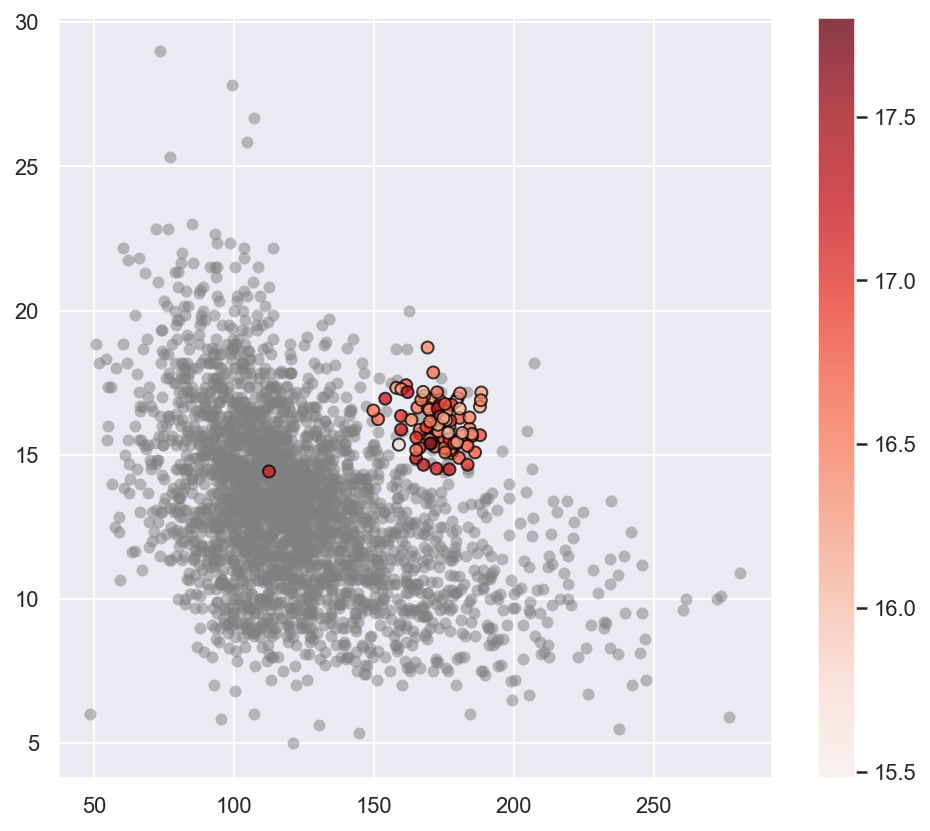

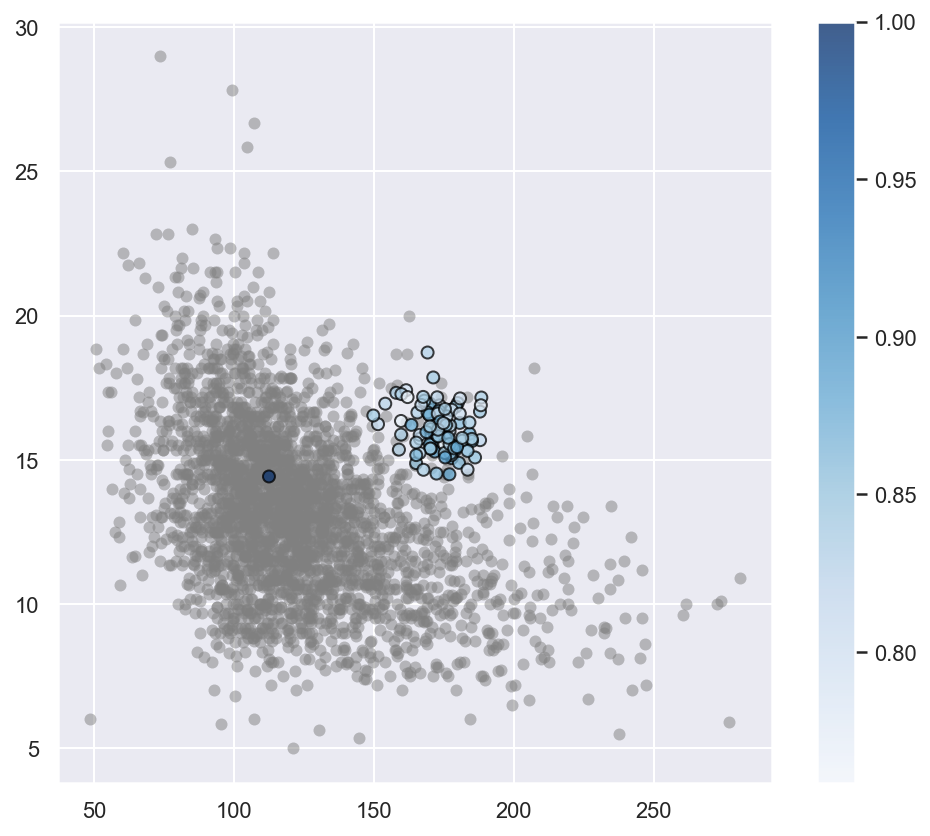

In [16]:
phenotype_data = pd.read_csv("../data/phenotype_data/mean_phenotypes.csv", index_col=0)

simulation_results = pd.read_csv("../data/PART8_Breeding_plan/N17_071_N08_011_simulation.csv", index_col=0)
simulation_results_scatter = simulation_results.T

plt.figure(figsize=(8,7))
sc = plt.scatter(phenotype_data["GN_mean"], phenotype_data["PN_mean"], alpha=0.5, linewidths=0, color="gray")
sc = plt.scatter(simulation_results_scatter["GN_mean"].astype(float), simulation_results_scatter["PN_mean"].astype(float), c=simulation_results_scatter["Area.size.AS..mm2."].astype(float), alpha=0.75, edgecolor="black", cmap="Reds")
plt.colorbar(sc)
plt.show()

plt.figure(figsize=(8,7))
sc = plt.scatter(phenotype_data["GN_mean"], phenotype_data["PN_mean"], alpha=0.5, linewidths=0, color="gray")
sc = plt.scatter(simulation_results_scatter["GN_mean"].astype(float), simulation_results_scatter["PN_mean"].astype(float), c=simulation_results_scatter["Hitome_ratio"].astype(float), alpha=0.75, edgecolor="black", cmap="Blues")
plt.colorbar(sc)
plt.show()

# Simulate New cultivar from N01_162 & N08_011

In [ ]:
random.seed(1024)

simulation_times = 100
Final_cultivars_Hitome_ratio = []
Final_cultivars_genotype = []
Final_cultivars_homo = []
fav_progenie_nums = []
for i in tqdm(range(simulation_times)):

    BCF2_num = 100
    # N01_162 x Hitomebore -> BCF1 -> 100 BCF2 
    # -> random select 1 BCF2 with target variants
    BCF2_N01_162 = BCF2("N01_162", RIL_info["N01_162"][0], genotype_Hitomebore, input_recom_data, BCF2_num)
    BCF2_N01_162_with_target, BCF2_N01_162_with_target_homo = get_genotypes_with_targets(BCF2_N01_162, "BCF2", N01_keep_marker_index)
    if len(BCF2_N01_162_with_target_homo) > 0:
        sum_marker = get_sum_of_marker_genotype(BCF2_N01_162_with_target_homo, "BCF2", N01_drop_marker_index)
        BCF2_N01_162_cand = BCF2_N01_162_with_target_homo[sum_marker.argsort()[0]]
    else:
        sum_marker = get_sum_of_marker_genotype(BCF2_N01_162_with_target, "BCF2", N01_drop_marker_index)
        BCF2_N01_162_cand = BCF2_N01_162_with_target[sum_marker.argsort()[0]]

    # N08_011 x Hitomebore -> BCF1 -> 100 BCF2 
    # -> random select 1 BCF2 with target variants
    BCF2_N08_011 = BCF2("N08_011", RIL_info["N08_011"][0], genotype_Hitomebore, input_recom_data, BCF2_num)
    BCF2_N08_011_with_target, BCF2_N08_011_with_target_homo = get_genotypes_with_targets(BCF2_N08_011, "BCF2", N08_keep_marker_index)
    if len(BCF2_N08_011_with_target_homo) > 0:
        sum_marker = get_sum_of_marker_genotype(BCF2_N08_011_with_target_homo, "BCF2", N08_drop_marker_index)
        BCF2_N08_011_cand = BCF2_N08_011_with_target_homo[sum_marker.argsort()[0]]
    else:
        sum_marker = get_sum_of_marker_genotype(BCF2_N08_011_with_target, "BCF2", N08_drop_marker_index)
        BCF2_N08_011_cand = BCF2_N08_011_with_target[sum_marker.argsort()[0]]
        
    # BCF2_N01_162_cand x BCF2_N08_011_cand
    # -> random select 1 progeny with target variants & high Hitomebore ratio
    mix_num = 100
    both_keep_marker = copy.copy(N01_keep_marker_index)
    both_keep_marker.extend(N08_keep_marker_index)
    mixed = [cross(BCF2_N01_162_cand, BCF2_N08_011_cand, "BCF2", "BCF2", "N01_N08_mixed", input_recom_data) for j in range(mix_num)]
    mixed_with_targets, _ = get_genotypes_with_targets(mixed, "N01_N08_mixed", both_keep_marker)
    both_drop_marker = copy.copy(N01_drop_marker_index)
    both_drop_marker.extend(N08_drop_marker_index)
    sum_marker = get_sum_of_marker_genotype(mixed_with_targets, "N01_N08_mixed", both_drop_marker)
    mixed_cand = mixed_with_targets[sum_marker.argsort()[0]]
    
    # -> inbreed to fix target variants
    mixed_2nd = [cross(mixed_cand, mixed_cand, "N01_N08_mixed", "N01_N08_mixed", "N01_N08_mixed_2nd", input_recom_data) for j in range(mix_num)]
    mixed_2nd_with_targets, mixed_2nd_with_targets_homo = get_genotypes_with_targets(mixed_2nd, "N01_N08_mixed_2nd", both_keep_marker)
    mixed_2nd_target_homo_ratio = get_sum_of_marker_genotype(mixed_2nd_with_targets, "N01_N08_mixed_2nd", both_keep_marker)
    mixed_cand = mixed_2nd_with_targets[mixed_2nd_target_homo_ratio.argsort()[-1]]
    
    # -> inbreed progeny that have highest homozygosity of target regions to fix target variants
    mixed_3rd = [cross(mixed_cand, mixed_cand, "N01_N08_mixed_2nd", "N01_N08_mixed_2nd", "N01_N08_mixed_3rd", input_recom_data) for j in range(mix_num)]
    mixed_3rd_with_targets, mixed_3rd_with_targets_homo = get_genotypes_with_targets(mixed_3rd, "N01_N08_mixed_3rd", both_keep_marker)
    sum_marker = get_sum_of_marker_genotype(mixed_3rd_with_targets_homo, "N01_N08_mixed_3rd", both_drop_marker)
    if len(mixed_3rd_with_targets_homo) > 0:
        Final_cultivars_Hitome_ratio.append(check_approximate_Hitomebore_ratio(mixed_3rd_with_targets_homo[sum_marker.argsort()[0]], "N01_N08_mixed_3rd", total_length))
        Final_cultivars_genotype.append(mixed_3rd_with_targets_homo[sum_marker.argsort()[0]])
        Final_cultivars_homo.append(True)
    else:
        mixed_3rd_target_homo_ratio = get_sum_of_marker_genotype(mixed_3rd_with_targets, "N01_N08_mixed_3rd", both_keep_marker)
        Final_cultivars_Hitome_ratio.append(check_approximate_Hitomebore_ratio(mixed_3rd_with_targets[mixed_3rd_target_homo_ratio.argsort()[-1]], "N01_N08_mixed_3rd", total_length))
        Final_cultivars_genotype.append(mixed_3rd_with_targets[mixed_3rd_target_homo_ratio.argsort()[-1]])
        Final_cultivars_homo.append(False)
    fav_progenie_nums.append([len(BCF2_N01_162_with_target), len(BCF2_N01_162_with_target_homo), len(BCF2_N08_011_with_target), len(BCF2_N08_011_with_target_homo), len(mixed_with_targets), len(mixed_3rd_with_targets_homo)])
pd.DataFrame(fav_progenie_nums).to_csv("../data/PART8_Breeding_plan/N01_162_N08_011_selection_stats.csv")

In [ ]:
# convert genotype data for simulation to genotype data for prediction
SNP_merged_num = marker_for_pred.shape[0]
Hitome_genotype = np.repeat(0, marker_for_pred.shape[0])
predict_genotype = [Hitome_genotype]
predict_genotype_name = ["Hitomebore"]
for i, convert_genotype in enumerate(Final_cultivars_genotype):
    convert_genotype["genotype"] = convert_genotype.loc[:, ["N01_N08_mixed_3rd_1", "N01_N08_mixed_3rd_2"]].sum(axis=1)
    convert_genotype["key"] = convert_genotype["chr"] + "_" + convert_genotype["start"].astype('str') + "_" + convert_genotype["end"].astype('str')
    convert_genotype = convert_genotype[convert_genotype.key.isin(marker_for_pred["key"])]
    predict_genotype.append(convert_genotype.genotype.values)
    predict_genotype_name.append(f"simulate_{i}")
predict_genotype = pd.DataFrame(predict_genotype)
predict_genotype.index = predict_genotype_name

In [ ]:
# predict phenotypic values of simulated lines & check genotypes of beneficial regions
k = 1
Hitome_ratio = [1]
Hitome_ratio.extend(Final_cultivars_Hitome_ratio)
target_homo = [False]
target_homo.extend(Final_cultivars_homo)
predicted_data = [Hitome_ratio, target_homo]
rate = np.repeat(1, len(Hitome_ratio))
for trait_name in ["GN_mean", "PN_mean", "Area.size.AS..mm2."]:
    print(trait_name)
    genotype_path = "../data/PART7_Select_useful_RILs/Haplotype_high_imp_HBs_for_3traits.csv" 
    test_data, train_data, position_data = make_data(family, family_list, trait_name, genotype_path, phenotype, CV, seed=1024, plot=False, log=False)
    ideal_preds = []
    for i in range(CV):
        Enet_params = pd.read_csv("../data/PART7_Select_useful_RILs/Enet_high_imp_HBs_params.csv", index_col=0)
        Enet_params.columns = ["trait", "CV", "params"]
        Enet_params = ast.literal_eval(Enet_params.loc[(Enet_params["trait"] == trait_name) & (Enet_params["CV"] == i), "params"].values[0])
        tmp_train_data = train_data[i] 
        X_train = tmp_train_data[0].fillna(0)
        y_train = tmp_train_data[1]
        
        # train model
        clf = ElasticNet(alpha=Enet_params["alpha"], l1_ratio=Enet_params["l1_ratio"], max_iter=100000)
        clf.fit(X_train, y_train)
        
        # predicted values of test phenotype
        ideal_pred = clf.predict(predict_genotype)
        ideal_preds.append(ideal_pred)
        
    # mean predicted values from CV1-5
    ideal_preds = np.mean(ideal_preds, axis=0)
    rate = [each_rate*ideal_preds[k]/ideal_preds[0] for k, each_rate in enumerate(rate)]
    predicted_data.append(ideal_preds)
    
# make dataframe of results
predicted_data.append(rate)
predicted_data = pd.DataFrame(predicted_data)
predicted_data.index = ["Hitome_ratio", "target_homo", "GN_mean", "PN_mean", "Area.size.AS..mm2.", "rate"]
predicted_data.columns = predict_genotype_name
predicted_data.to_csv("../data/PART8_Breeding_plan/N01_162_N08_011_simulation.csv")
predicted_data

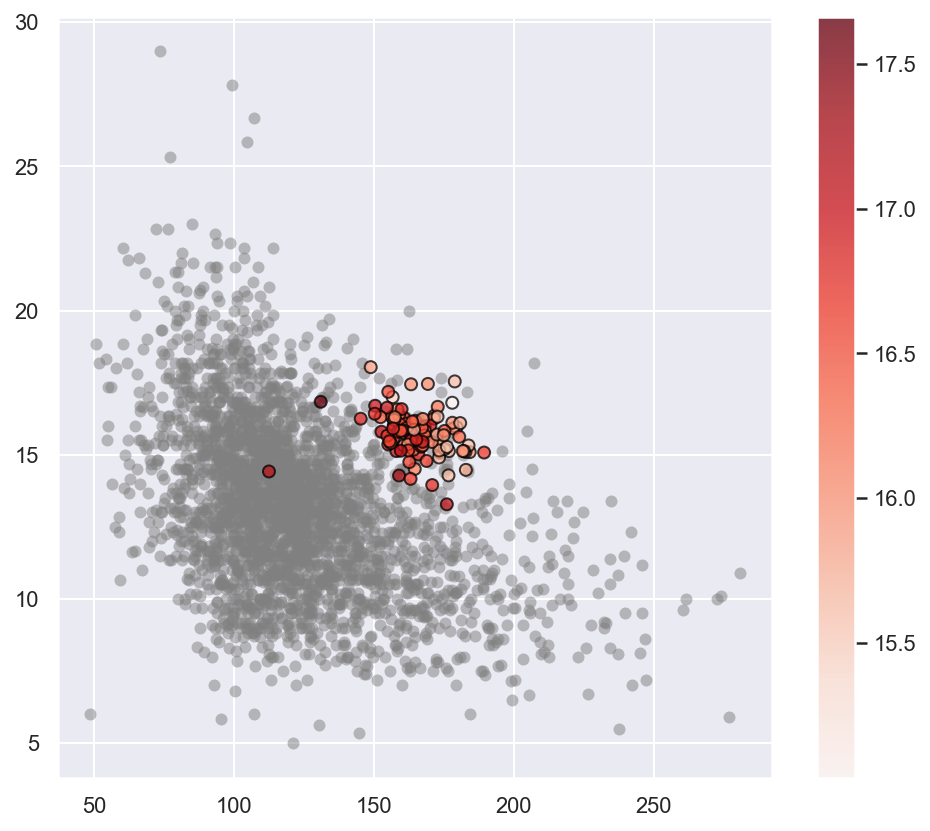

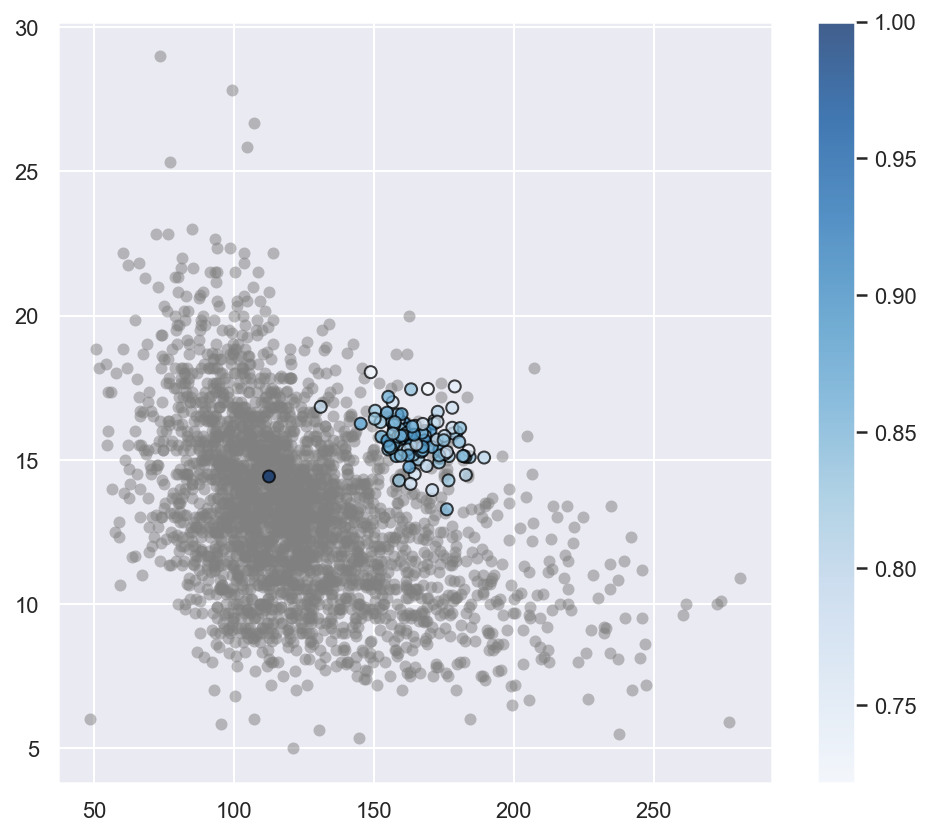

In [21]:
phenotype_data = pd.read_csv("../data/phenotype_data/mean_phenotypes.csv", index_col=0)
NAM_Hitome_ratio = pd.read_csv("../data/PART0_NAM_stats/Percentage_Hitomebore_genotype.csv")

simulation_results = pd.read_csv("../data/PART8_Breeding_plan/N01_162_N08_011_simulation.csv", index_col=0)
simulation_results_scatter = simulation_results.T

plt.figure(figsize=(8,7))
sc = plt.scatter(phenotype_data["GN_mean"], phenotype_data["PN_mean"], alpha=0.5, linewidths=0, color="gray")
sc = plt.scatter(simulation_results_scatter["GN_mean"].astype(float), simulation_results_scatter["PN_mean"].astype(float), c=simulation_results_scatter["Area.size.AS..mm2."].astype(float), alpha=0.75, edgecolor="black", cmap="Reds")
plt.colorbar(sc)
plt.show()

plt.figure(figsize=(8,7))
sc = plt.scatter(phenotype_data["GN_mean"], phenotype_data["PN_mean"], alpha=0.5, linewidths=0, color="gray")
sc = plt.scatter(simulation_results_scatter["GN_mean"].astype(float), simulation_results_scatter["PN_mean"].astype(float), c=simulation_results_scatter["Hitome_ratio"].astype(float), alpha=0.75, edgecolor="black", cmap="Blues")
plt.colorbar(sc)
plt.show()